In [6]:
import argparse
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from pathlib import Path


In [ ]:
def load_data(coverage_file, segmentation_file, bedpe_file):
    """Load the genomic data files"""
    # Load coverage data
    coverage = pd.read_csv(
        coverage_file, sep="\t", header=None, names=["chr", "start", "end", "total_cn"],
        dtype = {"chr": str, "start": np.int32, "end": np.int32, "total_cn": np.float64}
    )

    # Load segmentation data
    segmentation = pd.read_csv(
        segmentation_file,
        sep="\t",
        header=None,
        names=["chr", "start", "end", "total_cn", "min_cn"],
        dtype = {"chr": str, "start": np.int32, "end": np.int32, "total_cn": np.float64, "min_cn": np.float64}
    )

    bedpe_standard_names = {
        "0": "chr1",
        "1": "start1",
        "2": "end1",
        "3": "chr2",
        "4": "start2",
        "5": "end2",
        "6": "id",
        "7": "qual",
        "8": "strand1",
        "9": "strand2",
        "10": "info",
        "12": "cluster_id",
        "17": "complex_type",
        "19": "footprint_low",
        "20": "footprint_high",
    }
    bedpe_dtype = {
        0: str,
        1: np.int32,
        2: np.int32,
        3: str,
        4: np.int32,
        5: np.int32,
        6: str,
        7: np.float64,
        8: str,
        9: str,
        10: str,
        13: str,
        18: str,
        19: str,
        20: str,
    }

    # Load bedpe data (structural variants)
    bedpe = (
        pd.read_csv(
            bedpe_file,
            sep="\t",
            header=None,
            dtype=bedpe_dtype
        )
        .rename(columns=str)
        .rename(columns=bedpe_standard_names)
        # Make a short cluster label by taking the part after the last : (so …:10 → "10")
        .assign(
            cluster_short=lambda df: df["cluster_id"]
            .fillna(".")
            .apply(lambda x: x.split(":")[-1] if x != "NA" else x)
        )
        # Sort by chr position
        .sort_values(by=["chr1", "start1", "chr2", "start2"])
        .reset_index(drop=True)
    )
    # 1) cluster_size via value_counts
    counts = bedpe["cluster_short"].value_counts()
    # mapto bedpe
    bedpe["cluster_size"] = bedpe["cluster_short"].map(counts).fillna(0).astype(int)
    # 2) default to "simple"
    bedpe["sv_type"] = "simple"
    # 3) complex if complex_type starts with complex
    bedpe.loc[bedpe["complex_type"].str.startswith("complex", na=False), "sv_type"] = "complex"
    # 4) clustered if not complex and cluster_size >= 2
    bedpe.loc[(bedpe["sv_type"] != "complex") & (bedpe["cluster_size"] >= 2), "sv_type"] = "clustered"

    # Print a quick check: count how many rows have a non-missing cluster_id, and how many have complex_type starting with complex
    print(f"Loaded {bedpe.shape[0]} structural variants, {bedpe['cluster_short'].notna().sum()} with cluster_id, {bedpe['complex_type'].str.startswith('complex').sum()} complex")
    # Print counts per sv_type
    print(bedpe["sv_type"].value_counts())
    # Print counts per complex_type
    print(bedpe["complex_type"].value_counts())
    print(bedpe.head(5))

    return coverage, segmentation, bedpe


def sort_chromosomes(chr_list):
    """Sort chromosomes numerically (chr1, chr2, ... chr10, chr11, ...)"""

    def chr_key(chr_name):
        chr_name = str(chr_name)
        # Remove 'chr' prefix and handle special cases
        chr_num = chr_name.replace("chr", "")
        if chr_num.isdigit():
            return (0, int(chr_num))  # Numeric chromosomes first
        elif chr_num in ["X", "Y"]:
            return (1, ord(chr_num))  # X, Y after numeric
        else:
            return (2, chr_num)  # Others (MT, etc.) last

    return sorted(chr_list, key=chr_key)

    
def plot_chromosome(chr_name, coverage, segmentation, bedpe, ax_bottom):
    """
    Plot data for a single chromosome
    
    Args:
        chr_name (str): Chromosome name (e.g., 'chr1')
        coverage (DataFrame): Binned coverage data
        segmentation (DataFrame): Segmentation data
        bedpe (DataFrame): Structural variant data
        ax_bottom (Axes): Matplotlib Axes for the bottom panel (Coverage)
    """

    # Filter data for this chromosome
    chr_coverage = coverage[coverage["chr"] == chr_name].copy()
    chr_segmentation = segmentation[segmentation["chr"] == chr_name].copy()
    
    # Filter bedpe for breakpoints involving this chromosome
    chr_bedpe = bedpe[(bedpe["chr1"] == chr_name) | (bedpe["chr2"] == chr_name)].copy()
    # If no coverage or segmentation data, skip plotting
    if chr_coverage.empty:
        return

    # Calculate midpoints for plotting
    chr_coverage["midpoint"] = (chr_coverage["start"] + chr_coverage["end"]) / 2
    chr_segmentation["midpoint"] = (chr_segmentation["start"] + chr_segmentation["end"]) / 2

    ax_cn = ax_bottom          # left y-axis: copy number (seg + coverage)
    ax_sv = ax_cn.twinx()      # right y-axis: SV arcs in [0..1], using twinx() function to share y axis.
    ax_sv.set_ylim(0, 1)
    ax_sv.set_yticks([])       # hide ticks; it's a visual layer
    ax_sv.set_ylabel("SVs")

    # Bottom panel: Coverage and segmentation
    ax_bottom.scatter(
        chr_coverage["midpoint"],
        chr_coverage["total_cn"],
        s=1, # point size
        alpha=0.6, # alpha describes the transparency of the points
        color="lightblue",
        label="Binned Coverage",
    )

    # Set CN range
    y_min = 0
    y_max = 12
    ax_bottom.set_ylim(y_min, y_max)
    print(
        f"Processed {chr_name} binned covarge with tot_cn range from {y_min} to {y_max}"
    )
    # Plot segmentation as step function
    # segmentation as horizontal steps + faint boundaries
    for _, seg in chr_segmentation.iterrows():
        ax_cn.plot([seg["start"], seg["end"]],
                   [seg["total_cn"], seg["total_cn"]],
                   "r-", linewidth=2, alpha=0.8, label=None)
        ax_cn.axvline(seg["start"], color="red", linestyle="--", alpha=0.25, linewidth=0.6)
        ax_cn.axvline(seg["end"],   color="red", linestyle="--", alpha=0.25, linewidth=0.6)

    print(f"Processed {chr_name} with {chr_segmentation.shape[0]} segments")

    # Top panel: Structural variant breakpoints as arches
    max_pos = max(chr_coverage["end"].max(), chr_segmentation["end"].max())
    ax_cn.set_xlim(0, max_pos)
    ax_sv.set_xlim(0, max_pos)

    # collect positions per cluster that lie on THIS chromosome
    clusters = {}
    for _, sv in chr_bedpe.dropna(subset=["cluster_short"]).iterrows():
        cid = sv["cluster_short"]
        if cid not in clusters:
            clusters[cid] = {"pos": [], "n_sv": 0}
        if sv["chr1"] == chr_name:
            clusters[cid]["pos"].append(int(sv["start1"]))
        if sv["chr2"] == chr_name:
            clusters[cid]["pos"].append(int(sv["start2"]))
        clusters[cid]["n_sv"] += 1    # count this SV once

    # keep clusters with >=2 positions (so singletons don't get spans)
    min_svs_per_cluster = 2
    cluster_ids = [cid for cid, rec in clusters.items() if rec["n_sv"] >= min_svs_per_cluster]


    # stable colors per cluster (tab20) based on factor codes
    cmap = plt.get_cmap("tab20")
    codes = pd.factorize(cluster_ids)[0]
    cluster_color = {cid: cmap(int(code) % 20) for cid, code in zip(cluster_ids, codes)}

    # draw shaded spans & small labels near the top of SV band
    label_recs = []
    for cid in cluster_ids:
        rec = clusters[cid]
        xs = clusters[cid]["pos"]
        xmin, xmax_span = min(xs), max(xs)
        n_sv = clusters[cid]["n_sv"]
        ax_sv.axvspan(xmin, xmax_span, color=cluster_color[cid], alpha=0.18, zorder=0)
        mid = (xmin + xmax_span) / 2.0
        text = f"Cluster {str(cid).rsplit(':', 1)[-1]} (n={n_sv})"
        label_recs.append((xmin, xmax_span, mid, cid, text))

    label_recs.sort(key=lambda t: t[0])  # left → right

    lanes_y  = [0.95, 0.90, 0.85, 0.80]
    lane_end = [-np.inf] * len(lanes_y)

    # padding in data units between labels on the same lane
    chr_len = ax_sv.get_xlim()[1] - ax_sv.get_xlim()[0]
    pad_bp  = chr_len * 0.02                # 2% of chr length

    for xmin, xmax_span, mid, cid, text in label_recs:
        placed = False
        for i, y in enumerate(lanes_y):
            if xmin > (lane_end[i] + pad_bp):
                ax_sv.text(
                    mid, y, text,
                    ha="center", va="top", fontsize=8, color="black",
                    bbox=dict(
                        facecolor=cluster_color[cid],  # match label box to cluster color
                        alpha=0.70, boxstyle="round,pad=0.20", edgecolor="none"
                    ),
                    zorder=3,
                )
                lane_end[i] = xmax_span
                placed = True
                break
        if not placed:
            # fallback: drop it on the last lane anyway
            y = lanes_y[-1]
            ax_sv.text(
                mid, y, text,
                ha="center", va="top", fontsize=8, color="black",
                bbox=dict(facecolor=cluster_color[cid], alpha=0.70, boxstyle="round,pad=0.20", edgecolor="none"),
                zorder=3,
            )
            lane_end[-1] = max(lane_end[-1], xmax_span)

    # Plot arches for structural variants
    arch_height = 0.9
    arch_y = 0.1

    print(f"Processing {chr_name} with {chr_bedpe.shape[0]} structural variants")

    for _, sv in chr_bedpe.iterrows():
        # Choose color by cluster; complex overrides
        sv_color = cluster_color.get(sv.get("cluster_short"), "darkblue")  # singleton clusters fall back to gray
        if (sv["chr1"] == chr_name) and (sv["chr2"] == chr_name):
            x1, x2 = int(sv["start1"]), int(sv["start2"])
            if x1 == x2:
                continue
            center = (x1 + x2) / 2.0
            width  = abs(x2 - x1)
            arc = patches.Arc(
                (center, arch_y), width, arch_height,
                angle=0, theta1=0, theta2=180,
                color=sv_color, linewidth=1.5, alpha=0.8, zorder=2
            )
            ax_sv.add_patch(arc)
            ax_sv.plot([x1, x2], [arch_y, arch_y], "o",
                        markersize=2.5, alpha=0.85, color=sv_color, zorder=3)

        else:
            # inter-chrom: draw a small stub marker at the breakpoint on this chromosome
            if sv["chr1"] == chr_name:
                ax_sv.plot(int(sv["start1"]), arch_y, marker="s", markersize=3.5,
                           alpha=0.8, color=sv_color, linestyle="None", zorder=2)
            if sv["chr2"] == chr_name:
                ax_sv.plot(int(sv["start2"]), arch_y, marker="s", markersize=3.5,
                           alpha=0.8, color=sv_color, linestyle="None", zorder=2)
                
        # Cosmetics / labels
    ax_cn.grid(True, alpha=0.3)
    ax_cn.set_xlabel(f"{chr_name} position (bp)")
    ax_cn.set_ylabel("Copy number", labelpad=6)
    ax_sv.set_ylabel("SVs", labelpad=10)
    ax_cn.ticklabel_format(style="scientific", axis="x", scilimits=(6, 6))
    ax_cn.grid(True, alpha=0.3)
    
    # Build a tiny legend with two entries (bins + segments) using proxy handles
    bin_proxy = Line2D([0], [0], marker="o", linestyle="None", markersize=4,
                       color="lightblue", label="Coverage (bins)")
    seg_proxy = Line2D([0], [0], color="red", lw=2, label="Segments")
    ax_cn.legend(handles=[bin_proxy, seg_proxy], loc="upper right", frameon=False)
    sv_singleton = Line2D([0], [0], color="darkblue", lw=1.3, label="Singleton SV")
    ax_sv.legend(handles=[sv_singleton], loc="upper left", frameon=False)




def create_genomic_plot(
    coverage_file, segmentation_file, bedpe_file, chromosomes=None, output_file=None
):
    """Create the complete genomic visualization
    Args:
        coverage_file (str): Path to coverage file
        segmentation_file (str): Path to segmentation file
        bedpe_file (str): Path to BEDPE file
        chromosomes (list, optional): List of chromosomes to plot. If None, plot all.
        output_file (str, optional): Output PDF file path. If None, defaults to 'genomic_plot.pdf'.
    
    """

    # Load data
    coverage, segmentation, bedpe = load_data(
        coverage_file, segmentation_file, bedpe_file
    )

    # Get chromosomes to plot
    if chromosomes is None:
        chromosomes = sort_chromosomes(coverage["chr"].unique())
        # chromosomes = sorted(coverage["chr"].unique())

    # Create multi-page PDF
    with PdfPages(output_file) as pdf:
        for chr_name in chromosomes:
            # Create figure for this chromosome
            fig, ax = plt.subplots(figsize=(15, 6), constrained_layout=True)
            plot_chromosome(chr_name, coverage, segmentation, bedpe, ax)

            # Add chromosome title
            fig.suptitle(f"Chromosome {chr_name}", fontsize=16, fontweight="bold")

            # Add legends
            # ax_bottom.legend(loc="upper right")

            # Adjust layout
            plt.tight_layout()

            # Save page to PDF
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    plt.show()


# Example usage:
#if __name__ == "__main__":
#    parser = argparse.ArgumentParser(
#        description="Create genomic visualizations from coverage, segmentation, and structural variant data."
#    )
#
#    # Required arguments
#    parser.add_argument(
#        "--coverage", required=True, help="Path to coverage file (binned coverage data)"
#    )
#    parser.add_argument(
#        "--segmentation", required=True, help="Path to segmentation file"
#    )
#    parser.add_argument(
#        "--bedpe",
#        required=True,
#        help="Path to BEDPE file containing structural variants",
#    )
#
#    # Optional arguments
#    parser.add_argument(
#        "--output",
#        "-o",
#        default="genomic_plot.pdf",
#        help="Output PDF file path (default: genomic_plot.pdf)",
#    )
#    parser.add_argument(
#        "--chromosomes",
#        "-c",
#        nargs="+",
#        help="List of chromosomes to plot (e.g., chr1 chr2). If not specified, plots all chromosomes.",
#    )
#
#    args = parser.parse_args()
#
#    # Create the plot
#    create_genomic_plot(
#        coverage_file=args.coverage,
#        segmentation_file=args.segmentation,
#        bedpe_file=args.bedpe,
#        chromosomes=args.chromosomes,
#        output_file=args.output,
#    )
#
#    print(f"Plot created successfully! Output saved to: {args.output}")
#
#    # To plot all chromosomes, use:
#    # create_genomic_plot(coverage_file, segmentation_file, bedpe_file)
#

Loaded 296 structural variants, 296 with cluster_id, 152 complex
sv_type
complex      152
simple       115
clustered     29
Name: count, dtype: int64
complex_type
complex_unclear                                    152
inter                                               52
del                                                 28
td                                                  18
inv                                                 17
chromoplexy_cycle:2                                  8
shard_chain_insertion                                6
inversion_gain_loss                                  4
shard_chain:1                                        4
chromoplexy_cycle_plus_templated_insertions:2,1      3
split_translocation                                  2
direct_inversion                                     2
Name: count, dtype: int64
   chr1    start1      end1   chr2     start2       end2  \
0  chr1  30680312  30680313   chr9  129514722  129514723   
1  chr1  44815173  44815174  ch

/projects/supek_lab_shared/people/xvz782/tmp/ipykernel_392098/3934703453.py:196: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  codes = pd.factorize(cluster_ids)[0]
/projects/supek_lab_shared/people/xvz782/tmp/ipykernel_392098/3934703453.py:336: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


ValueError: fname must be a PathLike or file handle

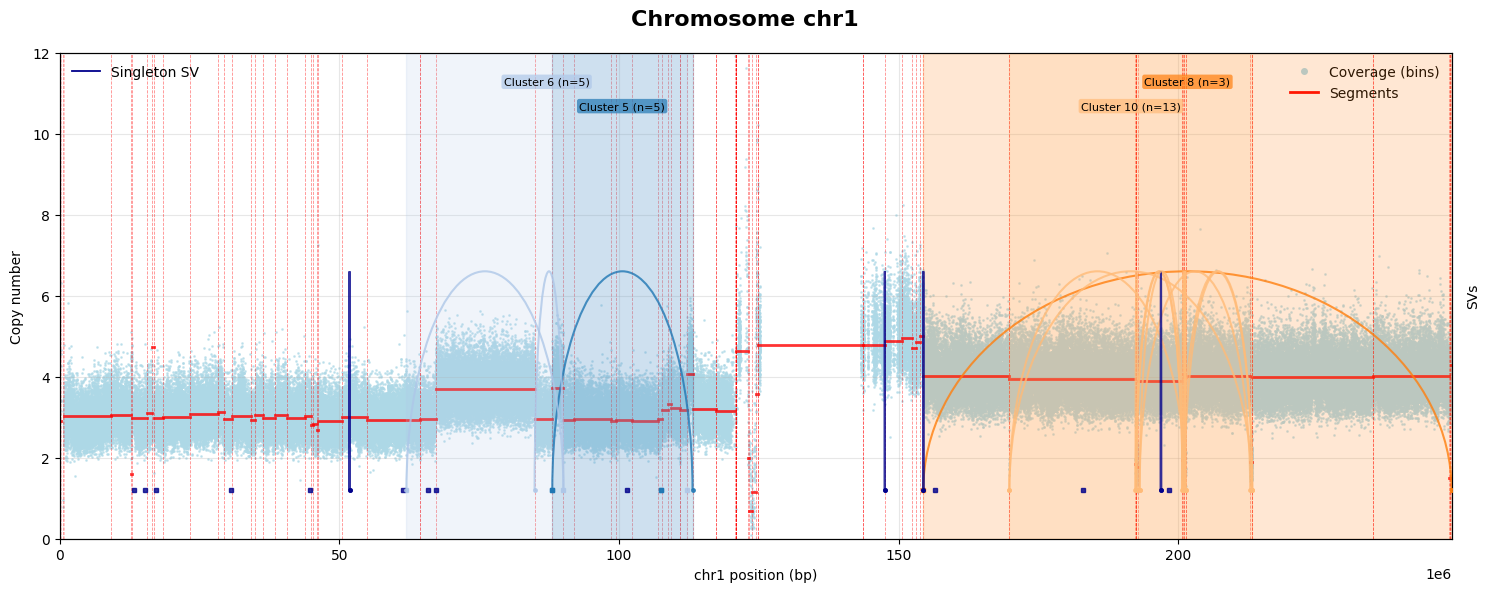

In [91]:
coverage_file = Path("/projects/weischenfeldt_lab-AUDIT/data/toolshed/20250926/data/TCGA-VP-A875-01A-31D-A730-36/TCGA-VP-A875-01A-31D-A730-36_binned_cov.txt")
segmentation_file = Path("/projects/weischenfeldt_lab-AUDIT/data/toolshed/20250926/data/TCGA-VP-A875-01A-31D-A730-36/TCGA-VP-A875-01A-31D-A730-36_segmentation.txt")
bedpe_file = Path("/projects/weischenfeldt_lab-AUDIT/data/toolshed/20250926/data/TCGA-VP-A875-01A-31D-A730-36/TCGA-VP-A875-01A-31D-A730-36_complex_sv_classification.bedpe")
create_genomic_plot(coverage_file, segmentation_file, bedpe_file, chromosomes=["chr1"])
load_data(coverage_file, segmentation_file, bedpe_file)

In [54]:
# Load the bedpe file as a DataFrame
bedpe_df = pd.read_csv(bedpe_file, sep="\t", header=None)

# Get unique values and their counts for column 12, exclude the ones with count = 1
value_counts=bedpe_df[12].value_counts()
filtered_value_counts=value_counts[value_counts == 1]
print(filtered_value_counts.sum())

115


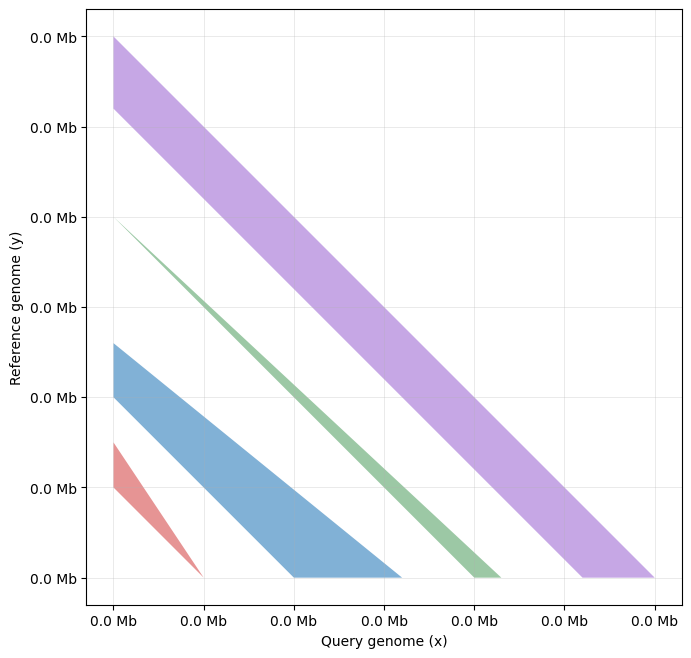

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.ticker import FuncFormatter

def mb_formatter(x, pos):  # Mb ticks
    return f"{x/1e6:.1f} Mb"

def add_block(ax, ref_start, ref_end, qry_start=None, qry_end=None,
              facecolor="#4C78A8", edgecolor="none", alpha=0.6, hatch=None):
    """
    Draw a filled synteny block connecting:
      - Reference interval on the y-axis: [ref_start, ref_end] at x=0
      - Query interval on the x-axis: [qry_start, qry_end] at y=0
    If qry_start==qry_end (or qry_end is None), the block tapers to a point.
    """
    if qry_end is None:  # allow single x position
        qry_end = qry_start

    # Clamp order
    y0, y1 = sorted([ref_start, ref_end])
    x0, x1 = sorted([qry_start, qry_end])

    # Polygon with vertices running around the perimeter:
    # left edge on y-axis, bottom edge on x-axis
    # If x0==x1, this becomes a triangle.
    verts = [(0, y0), (0, y1), (x1, 0), (x0, 0)]
    poly = Polygon(verts, closed=True, facecolor=facecolor, edgecolor=edgecolor,
                   alpha=alpha, hatch=hatch)
    ax.add_patch(poly)

def plot_synteny_blocks(events, x_label="Query genome (x)", y_label="Reference genome (y)",
                        fig_size=(7,7)):
    """
    events: list of dicts with keys:
      type: 'DEL'|'DUP'|'INS'|'INV' (affects styling only)
      ref_start, ref_end: coordinates on reference (bp)
      qry_start, qry_end: coordinates on query (bp); for DEL, set qry_start=ref_start and omit/==qry_end
                          for DUP, qry interval wider than ref
                          for INS, set ref_start≈ref_end (point) and give qry interval
    """
    fig, ax = plt.subplots(figsize=fig_size)

    for ev in events:
        t = ev["type"].upper()
        ref_start, ref_end = ev["ref_start"], ev["ref_end"]
        qry_start, qry_end = ev.get("qry_start"), ev.get("qry_end")

        # Styling by SV type
        if t == "DEL":
            color, hatch = "#D64D4D", None          # triangle to a point on x
            if qry_end is None:                     # allow shorthand
                qry_end = qry_start
        elif t == "DUP":
            color, hatch = "#2E7EBB", None          # trapezoid widening on x
        elif t == "INS":
            color, hatch = "#5AA469", None          # trapezoid widening on x from a point on y
        elif t == "INV":
            color, hatch = "#A06CD5", "//"          # same geometry; hatch indicates inversion
        else:
            color, hatch = "#7F7F7F", None

        add_block(ax, ref_start, ref_end, qry_start, qry_end, facecolor=color, hatch=hatch)

    # Axes & formatting
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.xaxis.set_major_formatter(FuncFormatter(mb_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(mb_formatter))
    ax.grid(True, alpha=0.3, linewidth=0.6)

    # Nice bounds
    # Expand to include all polygons comfortably
    xs = []
    ys = []
    for p in ax.patches:
        vx, vy = zip(*p.get_xy())
        xs.extend(vx); ys.extend(vy)
    pad_x = max(1, (max(xs) - min(xs)) * 0.05) if xs else 1
    pad_y = max(1, (max(ys) - min(ys)) * 0.05) if ys else 1
    ax.set_xlim(min(0, min(xs, default=0)) - pad_x, max(xs, default=1) + pad_x)
    ax.set_ylim(min(0, min(ys, default=0)) - pad_y, max(ys, default=1) + pad_y)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    return fig, ax

# ---- Examples ----
# 1) Deletion on chr6 between 50–75 (bp shown for simplicity; use real bp in practice):
example_events = [
    # DEL: reference y spans 50–75, query collapses to a point at x=50
    {"type": "DEL", "ref_start": 50, "ref_end": 75, "qry_start": 50},

    # DUP: reference 100–130 maps to a wider interval on x (e.g., 100–160)
    {"type": "DUP", "ref_start": 100, "ref_end": 130, "qry_start": 100, "qry_end": 160},

    # INS: small insertion at ref position 200, expands to 200–215 on x
    {"type": "INS", "ref_start": 200, "ref_end": 200, "qry_start": 200, "qry_end": 215},

    # INV: inverted mapping (geometry same; style via hatch)
    {"type": "INV", "ref_start": 260, "ref_end": 300, "qry_start": 300, "qry_end": 260},
]

fig, ax = plot_synteny_blocks(example_events)
plt.show()
